# HGND sensitivity — full analysis (post-cluster)

Analysis-only notebook. **Does not train and does not preprocess.** It
consumes the prediction pickles + sensitivity CSVs produced by
`slurm/sensitivity_full.sbatch` (or the local `scripts/run_sensitivity_full.sh`)
and produces paper-quality plots + summary tables.

Point `RESULTS_DIR` at the directory the SLURM run wrote to. Typical layout:

```
results/sensitivity_full_net_default_<job_id>/
├── checkpoints/
│   └── defaultSpot_net_default_full.pt
├── defaultSpot_net_default/
│   ├── pred_hits_full.pkl
│   ├── pred_clusters_full.pkl      ← consumed here
│   └── pred_edges_full.pkl
├── zeroSpot_net_default/    …
├── bigSpot_net_default/     …
└── sensitivity/
    ├── sensitivity_defaultSpot.csv ← consumed here
    ├── sensitivity_zeroSpot.csv
    ├── sensitivity_bigSpot.csv
    ├── sensitivity_combined.csv
    └── sensitivity_yield.png
```

Memory footprint: loads three pickled cluster DataFrames (~50–200 MB each
at full scale) plus the sensitivity CSVs. Trivial vs training.


In [1]:
import os, sys, glob, json as _json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

PACKAGE_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PACKAGE_ROOT not in sys.path:
    sys.path.insert(0, PACKAGE_ROOT)

from HGNDRecoGNN.analysis.sensitivity import (
    DatasetRun, compare_datasets, default_ekin_bins, DATASET_TO_POTENTIAL_MEV,
)
from HGNDRecoGNN.analysis.efficiency import (
    epsilon_neutron_vs_ekin, epsilon_vs_ekin_scan,
)

# EDIT THIS to point at the SLURM run directory:
RESULTS_DIR = os.environ.get(
    'HGND_RESULTS_DIR',
    os.path.abspath(os.path.join(os.getcwd(), '..', 'results',
                                 'sensitivity_full_net_default_local')),
)
MODEL       = os.environ.get('HGND_MODEL', 'net_default')
SUFFIX      = os.environ.get('HGND_SUFFIX', 'full')
THRESHOLD   = 0.5
DATASETS    = ['zeroSpot', 'defaultSpot', 'bigSpot']

print(f'RESULTS_DIR = {RESULTS_DIR}')
print(f'MODEL       = {MODEL}')
print(f'exists      = {os.path.isdir(RESULTS_DIR)}')


RESULTS_DIR = /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/notebooks/results/sensitivity_smoke
MODEL       = net_default
exists      = True


## 1. Discover which datasets have predictions

In [2]:
def pred_path(ds: str) -> str:
    return os.path.join(RESULTS_DIR, f'{ds}_{MODEL}', f'pred_clusters_{SUFFIX}.pkl')

available: dict[str, str] = {}
for ds in DATASETS:
    p = pred_path(ds)
    if os.path.exists(p):
        available[ds] = p
        print(f'  ✓ {ds:12s}  {p}')
    else:
        print(f'  ✗ {ds:12s}  missing at {p}')

if not available:
    raise FileNotFoundError(
        f'no prediction pickles under {RESULTS_DIR}. '
        'Update RESULTS_DIR at the top of the notebook or set HGND_RESULTS_DIR.'
    )


  ✓ zeroSpot      /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/notebooks/results/sensitivity_smoke/zeroSpot_net_default/pred_clusters_smoke.pkl
  ✓ defaultSpot   /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/notebooks/results/sensitivity_smoke/defaultSpot_net_default/pred_clusters_smoke.pkl
  ✓ bigSpot       /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/notebooks/results/sensitivity_smoke/bigSpot_net_default/pred_clusters_smoke.pkl


## 2. Load cluster predictions

In [3]:
cluster_dfs = {ds: pd.read_pickle(p) for ds, p in available.items()}
for ds, df in cluster_dfs.items():
    print(f'  {ds:12s}  {len(df):>8,} clusters  '
          f'{df["cl_label"].sum():>6,} signal  '
          f'e_true∈[{df["e_true"].min():.2f},{df["e_true"].max():.2f}] GeV')


  zeroSpot         2,550 clusters     326 signal  e_true∈[0.00,6.41] GeV
  defaultSpot      2,313 clusters     325 signal  e_true∈[0.00,6.79] GeV
  bigSpot          2,621 clusters     372 signal  e_true∈[0.00,6.55] GeV


## 2b. Dataset check plots

Per-dataset ground-truth checks *before* looking at anything reconstructed.
Templates copied from `NeutronRecoGNN/notebooks/results_smash.ipynb`.

For each dataset we load its raw-hits parquet cache (small on smoke
subsets; sliced by `Row` on full-scale caches) and plot in a 3-per-row
grid, one row per dataset:

- **MC-truth neutron spectrum** — one entry per unique `(Row, Id)` neutron
  track with `n0_label == 1`. This is what an ideal detector reports and
  should match the reference notebook for `defaultSpot`.
- **Neutron multiplicity** — `Nn` (all signal neutrons per event) from
  raw hits.
- **eToF signal vs background** — hit-level eToF distribution split by
  `n0_label`.

Datasets whose parquet cache is missing are skipped.


In [4]:
import glob
import resource

def _rss_gb():
    r = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return r / 1024 ** 3 if r > 10 ** 7 else r / 1024 ** 2

_PARQUET_COLS = ['Row', 'Instance', 'Id', 'fMotherId', 'PDG', 'Ekin',
                 'n0_label', 'eToF']

def _dataset_root_candidates(name: str) -> list[str]:
    """Where to look for a raw-hits parquet cache.

    The full-analysis notebook doesn't know where the SLURM/CLI run kept
    its preprocessed dataset. Try the common locations in order:
      1. HGND_DATASET_CACHE env var (explicit override)
      2. <RESULTS_DIR>/../../notebooks/cache/ndet_dataset_smash_<name>[_smoke]
      3. <RESULTS_DIR>/../cache/…              (SLURM writes here)
      4. <cwd>/cache/…                         (interactive)
    """
    env = os.environ.get('HGND_DATASET_CACHE')
    roots: list[str] = []
    if env:
        roots.append(env)
    for base in (os.path.join(RESULTS_DIR, '..', '..', 'notebooks', 'cache'),
                 os.path.join(RESULTS_DIR, '..', 'cache'),
                 os.path.join(os.getcwd(), 'cache')):
        roots.append(os.path.join(base, f'ndet_dataset_smash_{name}_smoke'))
        roots.append(os.path.join(base, f'ndet_dataset_smash_{name}'))
    return [os.path.abspath(r) for r in roots]

def _parquet_path(name: str) -> str | None:
    for root in _dataset_root_candidates(name):
        hits = glob.glob(os.path.join(root, 'processed', '_hits_cache_*.parquet'))
        if hits:
            return hits[0]
    return None

def load_check_frame(name: str, row_filter: set[int] | None = None) -> pd.DataFrame:
    """Load the raw-hits DataFrame slice needed for the check plots.

    Always call with row_filter = cluster_dfs[name]['Row'].unique() so the
    check frame is restricted to the events predict() actually saw. That
    way (a) memory stays tiny even on multi-GB parquets, and (b) the
    MC-truth spectrum plotted here matches the MC-truth reference drawn
    on top of the sensitivity plot below.
    """
    p = _parquet_path(name)
    if p is None:
        return pd.DataFrame(columns=_PARQUET_COLS)
    df = pd.read_parquet(p, columns=_PARQUET_COLS)
    if row_filter is not None:
        df = df[df['Row'].isin(row_filter)].copy()
    df['Nn'] = df[(df['n0_label'] == 1) & (df['Ekin'] > 0)].groupby('Row')['Id'].transform('nunique')
    df['Nn'] = df.groupby('Row')['Nn'].transform('max').fillna(0).astype(int)
    return df

# Build check DataFrames restricted to the test-split events of every
# dataset — matches cluster_dfs event counts so downstream normalisation
# stays consistent between plots.
TRAIN_DATASET = 'defaultSpot'
check_frames: dict[str, pd.DataFrame] = {}
for name, df in cluster_dfs.items():
    p = _parquet_path(name)
    if p is None:
        print(f'  {name:12s}  SKIP  no parquet cache found in candidate roots')
        continue
    row_set = set(df['Row'].unique())
    frame = load_check_frame(name, row_filter=row_set)
    check_frames[name] = frame
    mem_mb = frame.memory_usage(deep=True).sum() / 1e6
    print(f'  {name:12s}  hits={len(frame):>6,}  events={frame.Row.nunique():>4,}  '
          f'signal_hits={int((frame.n0_label==1).sum()):>5,}  {mem_mb:>5.1f} MB')
print(f'RSS after loading check frames: {_rss_gb():.2f} GB')


  zeroSpot      hits=15,353  events=1,000  signal_hits=2,084    1.2 MB


  defaultSpot   hits=14,699  events=1,024  signal_hits=2,012    1.2 MB
  bigSpot       hits=15,787  events=1,000  signal_hits=2,382    1.3 MB
RSS after loading check frames: 1.72 GB


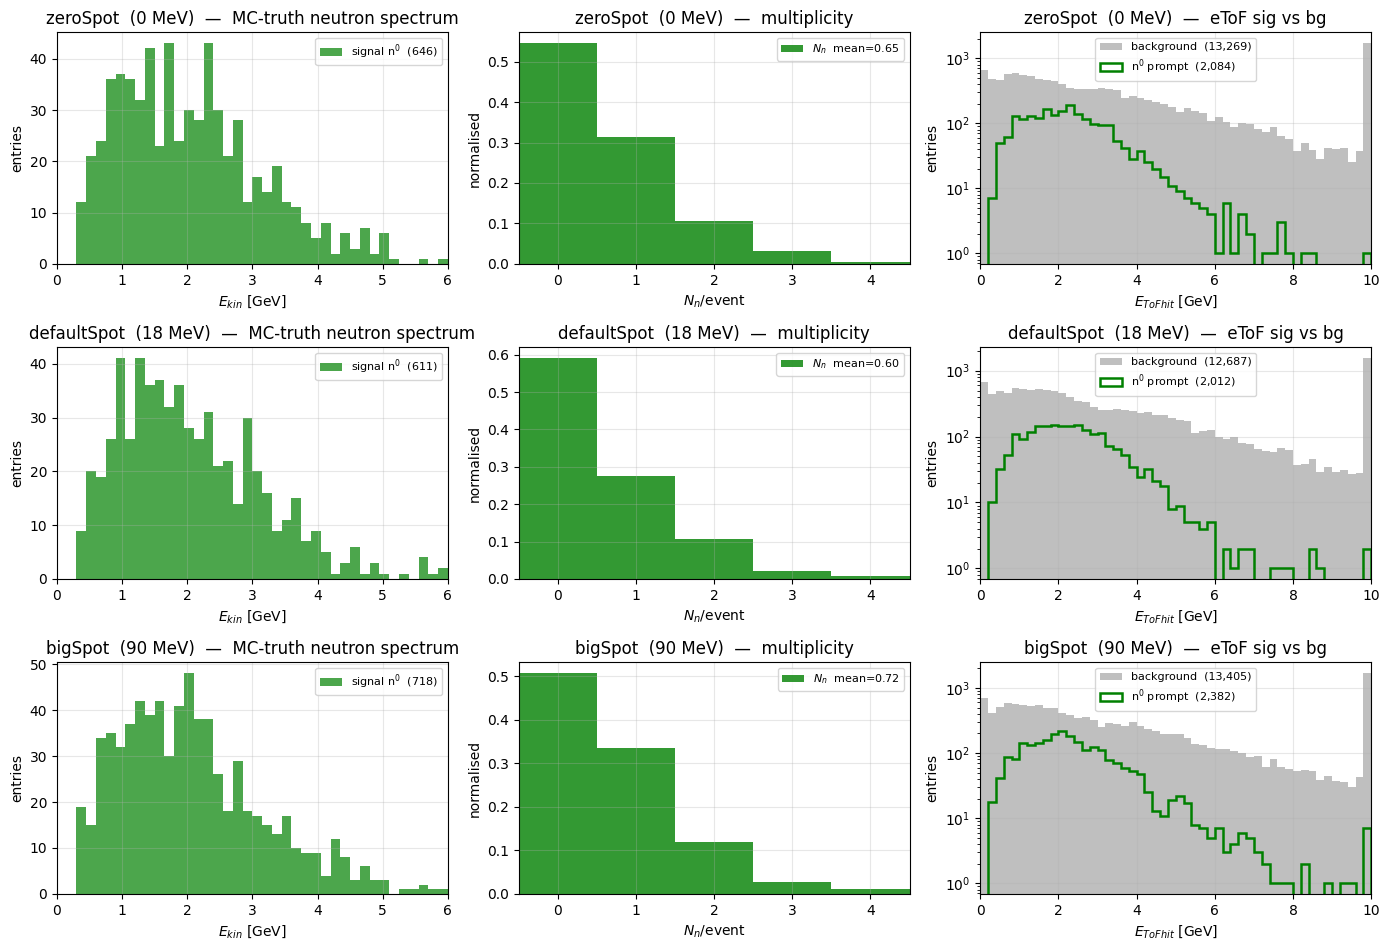

In [5]:
# 3×N grid: rows=datasets, cols=(MC-truth spectrum, multiplicity, eToF).
if check_frames:
    n = len(check_frames)
    fig, axes = plt.subplots(n, 3, figsize=(14, 3.2 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    E_RANGE  = (0, 6);      E_BINS   = 40
    MUL_RANGE = (-0.5, 4.5); MUL_BINS = 5
    ETOF_RANGE = (0, 10);   ETOF_BINS = 50

    for row_idx, (name, frame) in enumerate(check_frames.items()):
        pot = DATASET_TO_POTENTIAL_MEV.get(name)
        tag = f'{name}  ({pot:.0f} MeV)' if pot is not None else name

        # MC-truth spectrum — one entry per unique (Row, Id) signal neutron.
        ax = axes[row_idx, 0]
        mc_e = frame[frame.n0_label == 1].groupby(['Row', 'Id']).Ekin.mean()
        ax.hist(mc_e, bins=E_BINS, range=E_RANGE, alpha=0.7,
                color='green', label=f'signal n$^0$  ({len(mc_e):,})')
        ax.set_xlim(*E_RANGE); ax.set_xlabel(r'$E_{kin}$ [GeV]'); ax.set_ylabel('entries')
        ax.set_title(f'{tag}  —  MC-truth neutron spectrum'); ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        # Neutron multiplicity per event.
        ax = axes[row_idx, 1]
        nn = frame.groupby('Row').Nn.max()
        ax.hist(nn, bins=MUL_BINS, range=MUL_RANGE, density=True,
                color='green', alpha=0.8, label=f'$N_n$  mean={nn.mean():.2f}')
        ax.set_xlim(*MUL_RANGE); ax.set_xlabel(r'$N_{n}$/event')
        ax.set_ylabel('normalised'); ax.set_title(f'{tag}  —  multiplicity')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

        # eToF distribution — signal vs background hits.
        ax = axes[row_idx, 2]
        bg  = frame.loc[frame.n0_label == 0, 'eToF']
        sig = frame.loc[frame.n0_label == 1, 'eToF']
        ax.hist(bg,  bins=ETOF_BINS, range=ETOF_RANGE,
                color='grey', alpha=0.5, label=f'background  ({len(bg):,})')
        ax.hist(sig, bins=ETOF_BINS, range=ETOF_RANGE,
                histtype='step', linewidth=1.8, color='green',
                label=f'n$^0$ prompt  ({len(sig):,})')
        ax.set_xlim(*ETOF_RANGE); ax.set_xlabel(r'$E_{ToF hit}$ [GeV]')
        ax.set_ylabel('entries'); ax.set_yscale('log')
        ax.set_title(f'{tag}  —  eToF sig vs bg')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'dataset_check_grid.png'), dpi=130)
    plt.show()
else:
    print('no parquet caches discoverable — skipping dataset check grid')


## 2c. Model performance eval (defaultSpot, minimum details)

Classification quality of the trained model, evaluated on the held-out
test split of the training dataset. Templates from cells 10 / 14 / 22 / 25
of the reference notebook, stripped to one panel per metric.

These are diagnostics for the reconstruction step itself — orthogonal to
the cross-dataset sensitivity comparison below. Runs only if the
per-hit prediction pickle (`pred_hits_<SUFFIX>.pkl`) sits next to the
per-cluster one for the training dataset.


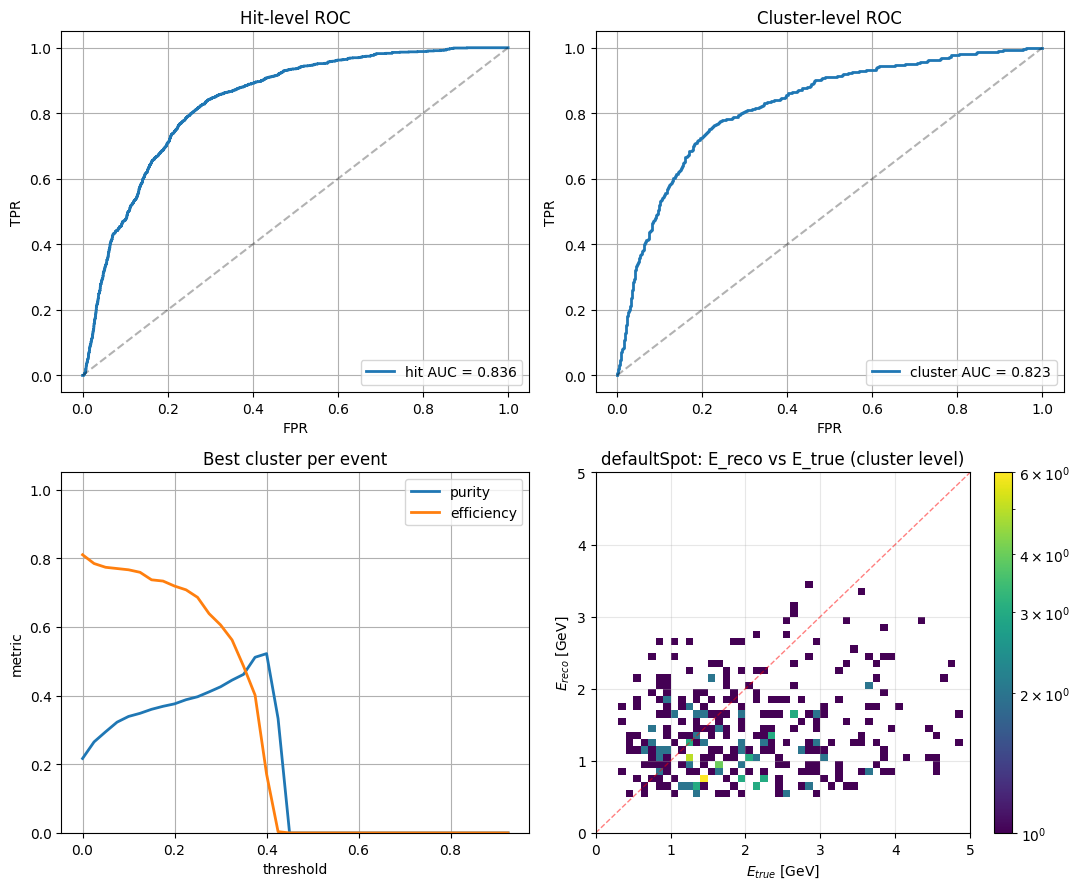

In [6]:
from sklearn.metrics import roc_auc_score, roc_curve
from matplotlib.colors import LogNorm

perf_ds = TRAIN_DATASET
_hits_path = os.path.join(RESULTS_DIR, f'{perf_ds}_{MODEL}',
                          f'pred_hits_{SUFFIX}.pkl')
if perf_ds not in cluster_dfs or not os.path.exists(_hits_path):
    print(f'  perf eval skipped: need {perf_ds} predictions + hits pkl at {_hits_path}')
else:
    clusters = cluster_dfs[perf_ds]
    hits_df = pd.read_pickle(_hits_path)

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))

    # (a) Hit-level ROC
    ax = axes[0, 0]
    if hits_df.label.nunique() > 1:
        fpr, tpr, _ = roc_curve(hits_df.label, hits_df.score)
        hit_auc = roc_auc_score(hits_df.label, hits_df.score)
        ax.plot(fpr, tpr, lw=2, label=f'hit AUC = {hit_auc:.3f}')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Hit-level ROC')
    ax.legend(loc=4); ax.grid(True)

    # (b) Cluster-level ROC (combined only — minimum details)
    ax = axes[0, 1]
    if clusters.cl_label.nunique() > 1:
        fpr, tpr, _ = roc_curve(clusters.cl_label, clusters.cl_score)
        cl_auc = roc_auc_score(clusters.cl_label, clusters.cl_score)
        ax.plot(fpr, tpr, lw=2, label=f'cluster AUC = {cl_auc:.3f}')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Cluster-level ROC')
    ax.legend(loc=4); ax.grid(True)

    # (c) Efficiency + purity vs threshold — best cluster per event.
    ax = axes[1, 0]
    best = clusters.sort_values('cl_score', ascending=False).groupby('Row').head(1).copy()
    n_total_signal_events = int(clusters[clusters.cl_label == 1]['Row'].nunique())
    ts = np.arange(0, 0.95, 0.025)
    purs, effs = [], []
    for t in ts:
        sel = best.cl_score > t
        n_sel = int(sel.sum())
        n_hit = int((sel & (best.cl_label == 1)).sum())
        purs.append(n_hit / max(n_sel, 1))
        effs.append(n_hit / max(n_total_signal_events, 1))
    ax.plot(ts, purs, lw=2, label='purity')
    ax.plot(ts, effs, lw=2, label='efficiency')
    ax.set_ylim(0, 1.05); ax.set_xlabel('threshold'); ax.set_ylabel('metric')
    ax.set_title('Best cluster per event'); ax.legend(loc=1); ax.grid(True)

    # (d) E_reco vs E_true 2D — cluster level.
    ax = axes[1, 1]
    sel = (clusters.cl_score > 0) & (clusters.e_true > 0)
    if sel.sum() > 10:
        h = ax.hist2d(clusters.loc[sel, 'e_true'], clusters.loc[sel, 'e_pred'],
                      range=[[0, 5], [0, 5]], bins=[50, 50], norm=LogNorm())
        plt.colorbar(h[3], ax=ax)
        ax.plot([0, 5], [0, 5], 'r--', lw=1, alpha=0.5)
    ax.set_xlabel(r'$E_{true}$ [GeV]'); ax.set_ylabel(r'$E_{reco}$ [GeV]')
    ax.set_title(f'{perf_ds}: E_reco vs E_true (cluster level)')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'performance_defaultSpot.png'), dpi=130)
    plt.show()


## 3. Efficiency ε_n(Ekin) per dataset

Same physics as `analysis/efficiency.py` — Wilson binomial intervals so
low-statistics bins don't collapse to 0 or 1 with zero uncertainty.

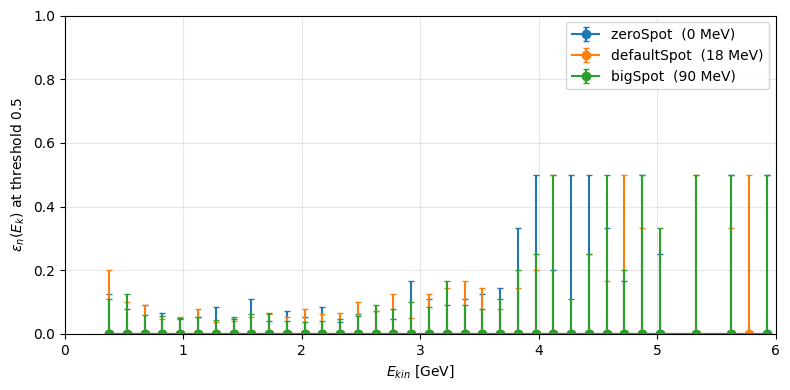

In [7]:
# Linear Ekin bins covering the full MC-truth support. 40 bins here so
# efficiency + yield + MC-truth plots all use the same grid as the §2b
# check plots — a shared x-axis makes the visual comparison honest.
bins = np.linspace(0.0, 6.0, 41)
eff_tables = {ds: epsilon_neutron_vs_ekin(df, bins, threshold=THRESHOLD)
              for ds, df in cluster_dfs.items()}

fig, ax = plt.subplots(figsize=(8, 4))
for ds, tab in eff_tables.items():
    lbl = f'{ds}  ({DATASET_TO_POTENTIAL_MEV.get(ds, np.nan):.0f} MeV)'
    ax.errorbar(tab['ekin_mid'], tab['epsilon'],
                yerr=[tab['epsilon'] - tab['epsilon_lo'],
                      tab['epsilon_hi'] - tab['epsilon']],
                marker='o', capsize=2, label=lbl)
ax.set_xlim(0, 6); ax.set_xlabel(r'$E_{kin}$ [GeV]')
ax.set_ylabel(r'$\varepsilon_n(E_k)$ at threshold ' + f'{THRESHOLD}')
ax.grid(True, alpha=0.3); ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'efficiency_vs_ekin.png'), dpi=150)
plt.show()


## 4. Solved neutron yield N_true(Ekin) per dataset

The observable of interest: `N_true(E) = N_reco(E) / ε(E)`, with
uncertainties propagated in quadrature (Poisson on reco + Wilson on ε).

events per dataset:
  zeroSpot      N_events = 1,000
  defaultSpot   N_events = 1,024
  bigSpot       N_events = 1,000


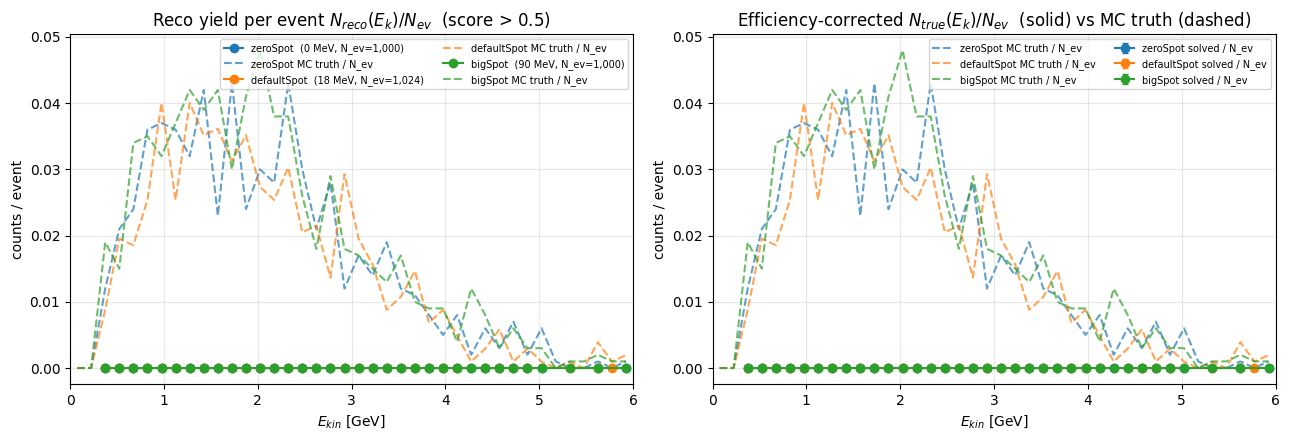

In [8]:
runs = [DatasetRun(name=ds, clusters_df=df) for ds, df in cluster_dfs.items()]
tables = compare_datasets(runs, bins, threshold=THRESHOLD)

# Per-event N_events for normalisation. `cluster_dfs[name]['Row']` is the
# authoritative event count seen at evaluation time — check_frames were
# already restricted to that same Row set in §2b.
n_events_by_ds = {name: int(df['Row'].nunique())
                  for name, df in cluster_dfs.items()}
print('events per dataset:')
for n, ne in n_events_by_ds.items():
    print(f'  {n:12s}  N_events = {ne:,}')

def _mc_truth_per_neutron(name, bins):
    """Per-event MC-truth from raw hits — one entry per unique (Row, Id)
    signal neutron. Matches the §2b check-grid MC-truth histogram
    exactly. Falls back to the per-cluster `n_mc_truth` from
    compare_datasets when the check frame is absent."""
    frame = check_frames.get(name)
    if frame is None or len(frame) == 0:
        return None, 0
    n_events = int(frame['Row'].nunique())
    mc_e = frame[frame['n0_label'] == 1].groupby(['Row', 'Id'])['Ekin'].mean()
    counts, _ = np.histogram(mc_e.to_numpy(), bins=bins)
    return counts, n_events

fig, (ax_reco, ax_solved) = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
mc_mid = 0.5 * (bins[:-1] + bins[1:])
for run in runs:
    tab = tables[run.name]
    n_ev = n_events_by_ds.get(run.name, 1)
    pot = DATASET_TO_POTENTIAL_MEV.get(run.name)
    lbl = (f'{run.name}  ({pot:.0f} MeV, N_ev={n_ev:,})'
           if pot is not None else f'{run.name}  (N_ev={n_ev:,})')
    line = ax_reco.plot(tab['ekin_mid'], tab['n_reco'] / n_ev,
                        marker='o', label=lbl)[0]
    ax_solved.errorbar(tab['ekin_mid'],
                       tab['n_true_solved'] / n_ev,
                       yerr=tab['n_true_solved_err'] / n_ev,
                       marker='o', capsize=2, color=line.get_color(),
                       label=f'{run.name} solved / N_ev')

    # MC-truth: per unique (Row, Id) signal neutron, from parquet.
    # Same recipe as the §2b check grid — the two views agree by construction.
    mc_counts, mc_nev = _mc_truth_per_neutron(run.name, bins)
    if mc_counts is not None and mc_nev > 0:
        ax_reco.plot(mc_mid, mc_counts / mc_nev,
                     ls='--', alpha=0.7, color=line.get_color(),
                     label=f'{run.name} MC truth / N_ev')
        ax_solved.plot(mc_mid, mc_counts / mc_nev,
                       ls='--', alpha=0.7, color=line.get_color(),
                       label=f'{run.name} MC truth / N_ev')
    else:
        # Fallback: cluster-level MC truth from compare_datasets, normalised.
        ax_reco.plot(tab['ekin_mid'], tab['n_mc_truth'] / n_ev,
                     ls=':', alpha=0.7, color=line.get_color(),
                     label=f'{run.name} MC (cluster-level) / N_ev')

ax_reco.set_title(r'Reco yield per event $N_{reco}(E_k)/N_{ev}$  (score > '
                  + f'{THRESHOLD})')
ax_solved.set_title(r'Efficiency-corrected $N_{true}(E_k)/N_{ev}$  '
                    r'(solid) vs MC truth (dashed)')
for ax in (ax_reco, ax_solved):
    ax.set_xlim(0, 6)
    ax.set_xlabel(r'$E_{kin}$ [GeV]'); ax.set_ylabel('counts / event')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sensitivity_yield_analysis.png'), dpi=150)
plt.show()


## 5. Pairwise ratios — the sensitivity signal

If the pipeline is genuinely sensitive to the symmetry potential, the
ratios `N_true(zeroSpot) / N_true(defaultSpot)` and
`N_true(bigSpot) / N_true(defaultSpot)` deviate from unity — larger
deviations mean more sensitivity. The uncertainty on a ratio is combined
in quadrature from the two independent Poisson+efficiency errors.

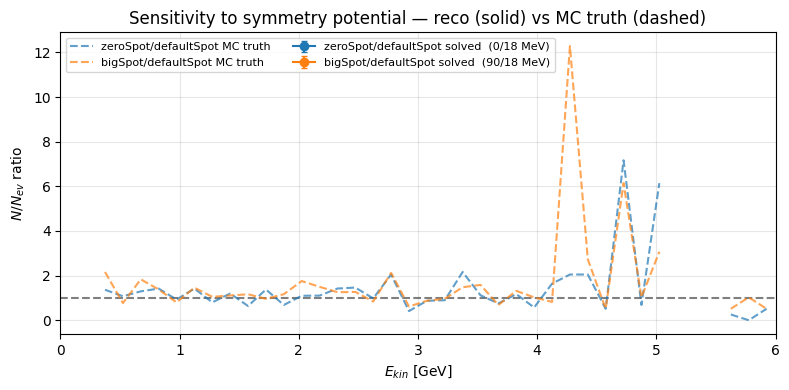

In [9]:
def _ratio(num_df, den_df, key='n_true_solved', err='n_true_solved_err',
           n_ev_num=1, n_ev_den=1):
    m = num_df.merge(den_df[['ekin_lo', 'ekin_hi', key, err]],
                     on=['ekin_lo', 'ekin_hi'], suffixes=('', '_den'))
    # Normalise numerator and denominator by per-dataset event count first
    # so datasets with mismatched N_events still give a meaningful ratio.
    num_per_ev = m[key] / max(n_ev_num, 1)
    den_per_ev = m[key + '_den'] / max(n_ev_den, 1)
    r = np.divide(num_per_ev, den_per_ev,
                  out=np.full(len(m), np.nan), where=den_per_ev > 0)
    with np.errstate(divide='ignore', invalid='ignore'):
        rel = np.sqrt((m[err] / m[key]) ** 2
                      + (m[err + '_den'] / m[key + '_den']) ** 2)
    return m['ekin_mid'], r, np.abs(r) * rel

def _mc_ratio(name_num, name_den, bins):
    """MC-truth per-event ratio (num/den) using the per-neutron histogram."""
    counts_n, ne_n = _mc_truth_per_neutron(name_num, bins)
    counts_d, ne_d = _mc_truth_per_neutron(name_den, bins)
    if counts_n is None or counts_d is None:
        return None
    with np.errstate(divide='ignore', invalid='ignore'):
        r = np.divide(counts_n / max(ne_n, 1), counts_d / max(ne_d, 1),
                      out=np.full(len(counts_n), np.nan),
                      where=counts_d > 0)
    return r

if 'defaultSpot' in tables and any(k in tables for k in ('zeroSpot', 'bigSpot')):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axhline(1.0, ls='--', c='k', alpha=0.5)
    ne_def = n_events_by_ds.get('defaultSpot', 1)
    mc_mid = 0.5 * (bins[:-1] + bins[1:])
    for ds in ('zeroSpot', 'bigSpot'):
        if ds not in tables:
            continue
        pot = DATASET_TO_POTENTIAL_MEV[ds]
        ne_ds = n_events_by_ds.get(ds, 1)
        # Reco/solved-yield ratio (per event)
        x, r, e = _ratio(tables[ds], tables['defaultSpot'],
                         n_ev_num=ne_ds, n_ev_den=ne_def)
        line = ax.errorbar(x, r, yerr=e, marker='o', capsize=2,
                           label=f'{ds}/defaultSpot solved  ({pot:.0f}/18 MeV)')[0]
        # MC-truth ratio as dashed reference — same colour.
        mc_r = _mc_ratio(ds, 'defaultSpot', bins)
        if mc_r is not None:
            ax.plot(mc_mid, mc_r, ls='--', alpha=0.7,
                    color=line.get_color(),
                    label=f'{ds}/defaultSpot MC truth')
    ax.set_xlim(0, 6)
    ax.set_xlabel(r'$E_{kin}$ [GeV]')
    ax.set_ylabel(r'$N/N_{ev}$ ratio')
    ax.set_title('Sensitivity to symmetry potential — reco (solid) vs MC truth (dashed)')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'sensitivity_ratios.png'), dpi=150)
    plt.show()
else:
    print('need at least defaultSpot + one of zeroSpot/bigSpot for ratio plot.')


## 6. Threshold-scan robustness check

Repeat the yield/efficiency computation across a range of decision
thresholds. If the shape of the sensitivity ratio survives the scan, the
pipeline's conclusion is robust to the cut choice.

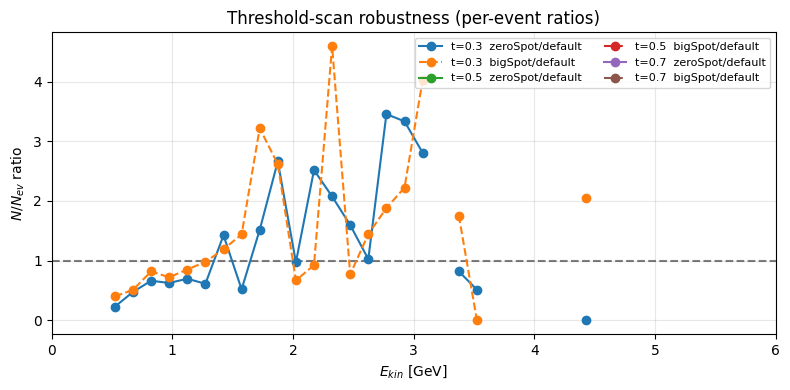

In [10]:
scan_thresholds = (0.3, 0.5, 0.7)
fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(1.0, ls='--', c='k', alpha=0.5)
ne_def = n_events_by_ds.get('defaultSpot', 1)
if 'defaultSpot' in cluster_dfs:
    for t in scan_thresholds:
        runs_t = [DatasetRun(name=ds, clusters_df=df) for ds, df in cluster_dfs.items()]
        tables_t = compare_datasets(runs_t, bins, threshold=t)
        for ds in ('zeroSpot', 'bigSpot'):
            if ds not in tables_t:
                continue
            ne_ds = n_events_by_ds.get(ds, 1)
            x, r, _ = _ratio(tables_t[ds], tables_t['defaultSpot'],
                             n_ev_num=ne_ds, n_ev_den=ne_def)
            ax.plot(x, r, marker='o',
                    ls='-' if ds == 'zeroSpot' else '--',
                    label=f't={t}  {ds}/default')
    ax.set_xlim(0, 6)
    ax.set_xlabel(r'$E_{kin}$ [GeV]')
    ax.set_ylabel(r'$N/N_{ev}$ ratio')
    ax.set_title('Threshold-scan robustness (per-event ratios)')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'sensitivity_threshold_scan.png'), dpi=150)
    plt.show()


## 7. Summary table

One row per dataset with headline numbers a paper caption can reuse.

In [11]:
summary_rows = []
for run in runs:
    tab = tables[run.name]
    n_ev = n_events_by_ds.get(run.name, 1)
    n_reco = int(tab['n_reco'].sum())
    n_true = float(tab['n_true_solved'].sum())
    n_true_err = float(np.sqrt((tab['n_true_solved_err'] ** 2).sum()))
    n_mc_cluster = int(tab['n_mc_truth'].sum())

    # Prefer the per-neutron MC truth from parquet when available (matches
    # the §2b check grid); fall back to per-cluster from compare_datasets.
    mc_counts, mc_nev = _mc_truth_per_neutron(run.name, bins)
    if mc_counts is not None and mc_nev > 0:
        n_mc = int(mc_counts.sum())
        n_mc_err = float(np.sqrt(n_mc))
        mc_source = 'parquet(per-neutron)'
    else:
        n_mc = n_mc_cluster
        n_mc_err = float(np.sqrt(n_mc))
        mc_source = 'cluster'

    pot = DATASET_TO_POTENTIAL_MEV.get(run.name)
    closure = (n_true / n_mc) if n_mc > 0 else float('nan')
    summary_rows.append({
        'dataset':      run.name,
        'U_sym_MeV':    pot,
        'threshold':    THRESHOLD,
        'N_events':     n_ev,
        'N_reco':       n_reco,
        'N_reco/ev':    round(n_reco / max(n_ev, 1), 3),
        'N_true':       round(n_true, 1),
        'N_true_err':   round(n_true_err, 1),
        'N_MC_truth':   n_mc,
        'N_MC_err':     round(n_mc_err, 1),
        'N_MC/ev':      round(n_mc / max(n_ev, 1), 3),
        'closure':      round(closure, 3),   # ~1.0 ⇒ ε correction is honest
        'MC_source':    mc_source,
    })
summary = pd.DataFrame(summary_rows).sort_values('U_sym_MeV')
summary.to_csv(os.path.join(RESULTS_DIR, 'sensitivity_summary.csv'), index=False)
summary


,dataset,U_sym_MeV,threshold,N_events,N_reco,N_reco/ev,N_true,N_true_err,N_MC_truth,N_MC_err,N_MC/ev,closure,MC_source
0,zeroSpot,0.0,0.5,1000,0,0.0,0.0,0.0,645,25.4,0.645,0.0,parquet(per-neutron)
1,defaultSpot,18.0,0.5,1024,0,0.0,0.0,0.0,610,24.7,0.596,0.0,parquet(per-neutron)
2,bigSpot,90.0,0.5,1000,0,0.0,0.0,0.0,716,26.8,0.716,0.0,parquet(per-neutron)


## 8. What to check before publishing

- `epsilon` in every bin > 0.1 and < 0.99 → statistical error is meaningful.
- Ratio plot deviations from 1.0 exceed the error bars → real sensitivity.
- Threshold-scan curves overlap → conclusion isn't a knife-edge artifact.
- Training loss curve (from the SLURM `.out` log) is monotonically
  decreasing and val loss doesn't blow up — otherwise the ε calibration
  is untrustworthy.

If any of the above fails, the escalation path is:
1. More epochs / larger model in `slurm/sensitivity_full.sbatch`.
2. Compare against `MODEL=hetero_hgt` (submit the sbatch as an array job).
3. If disagreement between models persists, tune the loss weights in
   `training/losses.py:LossWeights` and rerun.